# Global bound in the total-voltage basis $V_\mathrm{tot}$

Global bound on the radiated power with overall power conservation (real and imaginary part), formulated in the total voltage
$V_\mathrm{tot} = V - Z_0 I$ instead of the current $I$. Both constraints enter as general constraints of the dense QCQP
(no projector constraints).

The pointwise relation $I_i^*\left(Z_s I_i - V_{\mathrm{tot},i}\right) = 0$ holds for any structure, so the left factor must stay $I$.
The current is eliminated through the field equation, valid everywhere,
$$I = Z_0^{-1}\left(V - V_\mathrm{tot}\right) = b - W V_\mathrm{tot}, \qquad W = Z_0^{-1},\quad b = W V .$$
This is an invertible affine change of variables, so the bound must coincide with the global bound in the $I$ basis.

In [13]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [14]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [15]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## Objective in $V_\mathrm{tot}$

With $I = b - W V_\mathrm{tot}$ the radiated power $\tfrac12 I^H R_0 I$ takes the dolphindes form
$-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$, $x = V_\mathrm{tot}$, with
$$A_0 = -\tfrac12 W^H R_0 W,\qquad s_0 = -\tfrac12 W^H R_0 b,\qquad c_0 = \tfrac12 b^H R_0 b .$$

In [16]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T
bVec = W @ Vinc         # I = bVec - W Vtot

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = -0.5 * WH @ R0 @ bVec
obj0 = 0.5 * np.real(bVec.conj() @ R0 @ bVec)

def VtoI(Vtot):
    return(bVec - W @ Vtot)

def evalObj(Vtot):
    return(-np.real(Vtot.conj().T @ Obj @ Vtot) + 2*np.real(Vtot.conj().T @ obj) + obj0)

Vfull = Vinc - Z0 @ Ifull # total voltage for full plate
print(f"Objective for full plate in Vtot: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.750e+04
Objective for full plate in Vtot: 1.010821e+01 W (I basis 1.010821e+01 W)


## Global power conservation as general constraints

The global constraint $\operatorname{Re}\left[q\, I^H (V_\mathrm{tot} - Z_s I)\right] = 0$ with $q = 1$ (real power) and $q = -j$
(reactive power) becomes, after substituting $I = b - W V_\mathrm{tot}$, a general constraint
$\operatorname{Re}\left(-x^H B x + 2 x^H s + c\right) = 0$ with
$$B = \operatorname{Sym}\left[q\left(W^H + Z_s W^H W\right)\right],\qquad
s = \tfrac12\left[q^* b + 2\operatorname{Re}(q Z_s)\, W^H b\right],\qquad
c = -\operatorname{Re}(q Z_s)\, b^H b .$$
For $q = 1$, $B = W^H \operatorname{Re}(Z_\mathrm{tot}) W$ (using $\operatorname{Sym}W = W^H R_0 W$), the congruent image of the
$I$-basis real power constraint. Each constraint is normalized by $\|B\|_2$.

In [17]:
def powerConstraint(q):
    # general constraint Re[q I^H (Vtot - Zs I)] = 0 in Vtot, normalized by ||B||_2
    B = Msym(q*(WH + Zs * WH @ W))
    s = 0.5*(np.conj(q)*bVec + 2*np.real(q*Zs) * WH @ bVec)
    c = -np.real(q*Zs) * np.real(bVec.conj() @ bVec)
    sc = np.linalg.norm(B, 2)
    return B/sc, s/sc, c/sc, sc

qList = [1, -1j]   # real and imaginary part (real and reactive power)
cons = [powerConstraint(q) for q in qList]
B_j = [cn[0] for cn in cons]
s_2j = [cn[1] for cn in cons]
c_2j = [cn[2] for cn in cons]
scales = np.array([cn[3] for cn in cons])

def genRes(x, j):
    return(np.real(-x.conj() @ B_j[j] @ x + 2*x.conj() @ s_2j[j]) + c_2j[j])

def directRes(Vtot, q):
    # Re[q I^H (Vtot - Zs I)] evaluated directly
    I = VtoI(Vtot)
    return(np.real(q * I.conj() @ (Vtot - Zs*I)))

print("power conservation residuals at full plate:",
      [f"{genRes(Vfull, j):.2e} (direct {directRes(Vfull, q)/scales[j]:.2e})" for j, q in enumerate(qList)])

power conservation residuals at full plate: ['-4.39e-13 (direct -4.39e-13)', '6.06e-11 (direct 6.06e-11)']


## Dual problem

Only general constraints are used, so the projector list is empty (`Pstruct` must then be passed explicitly, `A1`, `s1` are unused).
The unnormalized real power multiplier $\lambda > \tfrac12$ makes $A = -\tfrac12 W^H R_0 W + \lambda W^H \operatorname{Re}(Z_\mathrm{tot}) W$
positive definite, which gives a dual feasible starting point.

In [18]:
QCQP = DenseSharedProjQCQP(
    Obj, obj, obj0,
    np.zeros((Ndes, Ndes), dtype=complex), np.zeros(Ndes, dtype=complex),
    [], Pstruct=sp.eye_array(Ndes, format='csc'),
    B_j=B_j, s_2j=s_2j, c_2j=c_2j,
    verbose=1,
)

lags_init = np.array([1.0*scales[0], 0.0])   # unnormalized lambda = 1 on the real power constraint
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags} "
      f"(unnormalized {QCQP.current_lags/scales})")

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.012093e+01 W, time: 0.07s, Lagrange multipliers: [ 0.83782238 -0.00164566] (unnormalized [ 0.98806809 -0.03777126])


In [19]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{genRes(Vstar, j):.2e}" for j in range(len(qList))])

minimum eigenvalue of A: 1.813e-06
dual bound 1.012093e+01 W, P(x*) 1.012093e+01 W (I basis 1.012093e+01 W), full plate 1.010821e+01 W
constraint residuals at x*: ['8.05e-08', '-1.33e-06']


## Reference: global bound in the $I$ basis

Same constraints with shared projectors in the current basis (as in `densityConstraintsImag.ipynb`). The bounds must agree.

In [20]:
Umat = -1j * Ztot.conj()/np.conj(Zs)   # A1 = U^H with U = j Ztot (Ztot symmetric)
eVec = 1j * Vinc / 2/Zs
Pdiags = np.conj(Zs) * np.column_stack([np.ones(Ndes), 1j*np.ones(Ndes)]).astype(complex)  # global: Im and Re part
Plist = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]

QCQP_I = DenseSharedProjQCQP(-0.5*R0, np.zeros(Ndes, dtype=complex), 0, Umat, eVec, Plist, verbose=0)
resultI = QCQP_I.solve_current_dual_problem(method='newton', init_lags=np.array([0.0, 1.0]), opt_params=opt_params)
print(f"I basis bound: {resultI[0]:.6e} W, Vtot basis bound: {result[0]:.6e} W, relative difference {abs(resultI[0]-result[0])/resultI[0]:.2e}")
print(f"relative difference of x*: {np.linalg.norm(QCQP_I.current_xstar - Istar)/np.linalg.norm(QCQP_I.current_xstar):.2e}")

I basis bound: 1.012093e+01 W, Vtot basis bound: 1.012093e+01 W, relative difference 1.54e-12
relative difference of x*: 3.88e-08


## Local projector constraints in $V_\mathrm{tot}$

For a complex diagonal projector $P = \operatorname{diag}(p)$ the local constraint $\operatorname{Re}\left[I^H P (V_\mathrm{tot} - Z_s I)\right] = 0$
holds for any structure. With $I = b - W V_\mathrm{tot}$ it becomes the general constraint $\operatorname{Re}\left(-x^H B x + 2x^H s + c\right) = 0$,
$$B = \operatorname{Sym}\left[W^H P (1 + Z_s W)\right],\qquad
s = \tfrac12\left[(1 + Z_s^* W^H)\, P^* b + Z_s W^H P b\right],\qquad
c = -\operatorname{Re}\left(Z_s\, b^H P b\right),$$
which reduces to the global constraints for $p = q\mathbf 1$. The affine change of variables leaves the constant $c$ in every local
constraint, which the shared projector form $\operatorname{Re}(-x^H A_1 P A_2 x + 2x^H A_2^H P^H s_1)$ cannot hold, so the local
constraints are added as general constraints.

New projectors follow `dolphindes.cvxopt.gcd.run_gcd`. Writing the constraint as $\operatorname{Re}\sum_i p_i w_i$:

1. **Strongest local violation:** the dual gradient of the constraint is its value at $x^\star$, maximized by
   $p_i = w_i^*$ with $w_i = I_i^{\star *}\left(V^\star_{\mathrm{tot}} - Z_s I^\star\right)_i$, $I^\star = b - W x^\star$
   (`maxViol_Pdiag` with $A_1 = W^H$, $A_2 = 1 + Z_s W$).
2. **Minimal eigenvalue:** for the eigenvector $v$ of $A(\lambda)$ with the smallest eigenvalue, $\partial\lambda_\mathrm{min} = v^H B v
   = \operatorname{Re}\sum_i p_i (Wv)_i^* \left((1+Z_sW)v\right)_i$, maximized by $p_i = (Wv)_i\left((1+Z_sW)v\right)_i^*$,
   normalized elementwise to unit modulus (`minAeig_Pdiag`).

Each new projector is Gram-Schmidt orthonormalized (real inner product $\operatorname{Re}\, p^H p'$) against all previous ones,
including the global $p = \mathbf 1$ and $p = -j\mathbf 1$, the constraint is normalized by $\|B\|_2$, and enters with a zero multiplier,
so the previous multipliers remain a feasible warm start. Each of the `Nloc` steps adds both constraints and re-solves the dual.

In [21]:
from dolphindes.util import Sym

def localConstraint(p):
    # general constraint Re[I^H diag(p) (Vtot - Zs I)] = 0 in Vtot, normalized by ||B||_2
    B = Msym(WH @ (p[:, None] * (np.eye(Ndes) + Zs*W)))
    s = 0.5*((np.conj(p)*bVec + np.conj(Zs) * WH @ (np.conj(p)*bVec)) + Zs * WH @ (p*bVec))
    c = -np.real(Zs * np.sum(p*np.abs(bVec)**2))
    sc = np.linalg.norm(B, 2)
    return B/sc, s/sc, c/sc

def localRes(Vtot, p):
    # Re[I^H diag(p) (Vtot - Zs I)] evaluated directly
    I = VtoI(Vtot)
    return(np.real(np.sum(p*np.conj(I)*(Vtot - Zs*I))))

def addGenConstraint(Q, B, s, c):
    # append a general constraint to Q with a zero multiplier
    Q.B_j.append(np.asarray(B, dtype=complex))
    Q.s_2j.append(np.asarray(s, dtype=complex))
    Q.c_2j = np.append(Q.c_2j, c)
    Q.n_gen_constr = len(Q.B_j)
    Q.precomputed_As.append(Sym(Q.A2.conj().T @ Q.B_j[-1] @ Q.A2))
    Q.Fs = np.column_stack([Q.Fs, Q.A2.conj().T @ Q.s_2j[-1]])
    Q.current_lags = np.append(Q.current_lags, 0.0)
    Q.current_grad = Q.current_hess = None
    Q._invalidate_factor_cache()

def orthonormalize(p, basis):
    # modified Gram-Schmidt in the real inner product Re(p^H p'); None if p is in the span
    p = np.array(p, dtype=complex)
    norm0 = np.linalg.norm(p)
    for q in basis:
        p = p - np.real(np.vdot(q, p)) * q
    if np.linalg.norm(p) < 1e-10 * norm0:
        return None
    return p / np.linalg.norm(p)

# check: local constraint with p = 1 reproduces the global real power constraint, residual at full plate for random p
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
Bc, sc_, cc = localConstraint(np.ones(Ndes, dtype=complex))
print(f"p = 1 vs global real power: |dB| {np.linalg.norm(Bc - B_j[0]):.2e}, |ds| {np.linalg.norm(sc_ - s_2j[0]):.2e}, |dc| {abs(cc - c_2j[0]):.2e}")
Bc, sc_, cc = localConstraint(pRand)
print(f"random p at full plate: general {np.real(-Vfull.conj() @ Bc @ Vfull + 2*Vfull.conj() @ sc_) + cc:.2e}, "
      f"direct {localRes(Vfull, pRand)/np.linalg.norm(Msym(WH @ (pRand[:, None] * (np.eye(Ndes) + Zs*W))), 2):.2e}")

p = 1 vs global real power: |dB| 3.36e-16, |ds| 2.07e-16, |dc| 5.55e-17
random p at full plate: general -3.82e-11, direct -3.82e-11


In [22]:
import copy

Nloc = 60   # number of steps, each adds a max violation and a min eigenvalue projector

lQCQP = copy.deepcopy(QCQP)
lQCQP.verbose = 0
pBasis = [np.ones(Ndes, dtype=complex)/np.sqrt(Ndes), -1j*np.ones(Ndes, dtype=complex)/np.sqrt(Ndes)]   # global projectors
ZW = np.eye(Ndes) + Zs*W   # A2 of the local constraints

def localViolation(Vtot):
    # pointwise w_i = I_i^* (Vtot - Zs I)_i, zero for any physical structure
    I = VtoI(Vtot)
    return(np.conj(I)*(Vtot - Zs*I))

history = [(0, lQCQP.current_dual, np.linalg.norm(localViolation(lQCQP.current_xstar)), np.nan)]
t1 = time.time()
for it in range(1, Nloc + 1):
    xstar = lQCQP.current_xstar
    newP = []

    # 1. projector against the strongest local violation (max dual gradient)
    maxViol_Pdiag = np.conj(localViolation(xstar))
    if np.linalg.norm(maxViol_Pdiag) >= 1e-14:
        newP.append(maxViol_Pdiag)

    # 2. projector maximizing the derivative of the minimal eigenvalue of A
    minAeigv, minAeigw = lQCQP._get_PSD_penalty(lQCQP.current_lags)
    minAeig_Pdiag = (W @ minAeigv) * np.conj(ZW @ minAeigv)
    minAeig_Pdiag /= np.abs(minAeig_Pdiag)
    newP.append(minAeig_Pdiag)

    nAdded = 0
    for p in newP:
        p = orthonormalize(p, pBasis)
        if p is None:
            continue
        pBasis.append(p)
        addGenConstraint(lQCQP, *localConstraint(p))
        nAdded += 1

    lQCQP.solve_current_dual_problem(method='newton', init_lags=lQCQP.current_lags, opt_params=opt_params)
    err = np.linalg.norm(localViolation(lQCQP.current_xstar))
    history.append((it, lQCQP.current_dual, err, minAeigw))
    print(f"[{it:2d}] bound {lQCQP.current_dual:.6e} W, {lQCQP.n_gen_constr} constraints (+{nAdded}), "
          f"min eig before {minAeigw:.3e}, ||local violation|| {err:.3e}, {time.time()-t1:.2f}s", flush=True)

history = np.array(history)
print(f"bound: {history[0, 1]:.6e} -> {history[-1, 1]:.6e} W (full plate {Pfull:.6e} W)")

[ 1] bound 1.011320e+01 W, 4 constraints (+2), min eig before 1.813e-06, ||local violation|| 1.180e+00, 0.09s
[ 2] bound 1.011318e+01 W, 6 constraints (+2), min eig before 1.421e-06, ||local violation|| 9.704e-01, 0.21s
[ 3] bound 1.011294e+01 W, 8 constraints (+2), min eig before 1.420e-06, ||local violation|| 3.888e+00, 0.33s
[ 4] bound 1.011188e+01 W, 10 constraints (+2), min eig before 1.408e-06, ||local violation|| 4.657e+00, 0.46s
[ 5] bound 1.011140e+01 W, 12 constraints (+2), min eig before 1.353e-06, ||local violation|| 3.532e+00, 0.61s
[ 6] bound 1.011103e+01 W, 14 constraints (+2), min eig before 1.326e-06, ||local violation|| 2.611e+00, 0.77s
[ 7] bound 1.011088e+01 W, 16 constraints (+2), min eig before 1.305e-06, ||local violation|| 1.837e+00, 0.93s
[ 8] bound 1.011080e+01 W, 18 constraints (+2), min eig before 1.296e-06, ||local violation|| 1.500e+00, 1.12s
[ 9] bound 1.011072e+01 W, 20 constraints (+2), min eig before 1.291e-06, ||local violation|| 1.569e+00, 1.33s
[10]

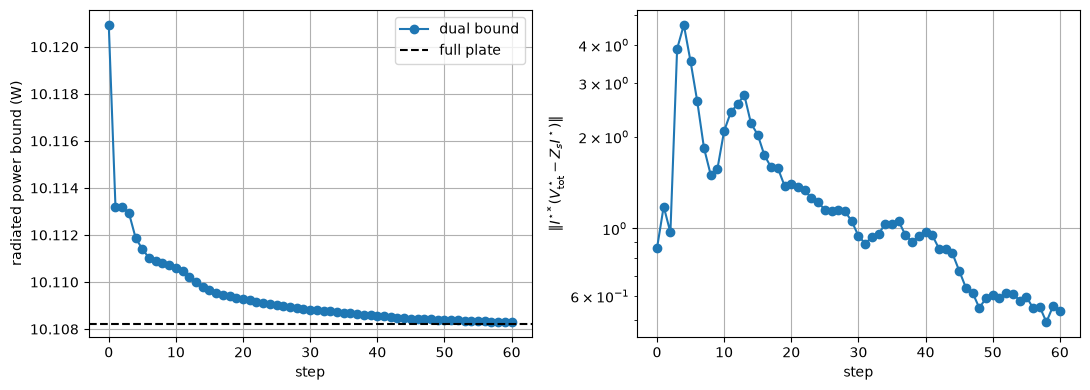

minimum eigenvalue of A: 1.101e-06
dual bound 1.010830e+01 W, P(x*) 1.010830e+01 W
max |constraint residual| at x*: 8.46e-08 (global), 1.39e-04 (all)


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history[:, 0], history[:, 1], 'o-', label='dual bound')
axes[0].axhline(Pfull, color='k', ls='--', label='full plate')
axes[0].set_xlabel('step'); axes[0].set_ylabel('radiated power bound (W)'); axes[0].legend(); axes[0].grid(True)
axes[1].semilogy(history[:, 0], history[:, 2], 'o-')
axes[1].set_xlabel('step'); axes[1].set_ylabel(r'$\|I^{\star *}(V^\star_\mathrm{tot} - Z_s I^\star)\|$'); axes[1].grid(True)
plt.tight_layout(); plt.show()

Vstar = lQCQP.current_xstar
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(lQCQP._get_total_A(lQCQP.current_lags)))):.3e}")
print(f"dual bound {lQCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W")
print(f"max |constraint residual| at x*: {max(abs(genRes(Vstar, j)) for j in range(2)):.2e} (global), "
      f"{max(abs(np.real(-Vstar.conj() @ B @ Vstar + 2*Vstar.conj() @ s) + c) for B, s, c in zip(lQCQP.B_j, lQCQP.s_2j, lQCQP.c_2j)):.2e} (all)")

## Inferred complex material density

Material density per basis function (as in `densityConstraintsImag.ipynb`), directly in the total voltage,
$$\rho_i = \frac{Z_s I_i}{V_{\mathrm{tot},i}}, \qquad I = b - W V_\mathrm{tot},$$
equal to 1 on material and 0 on empty basis functions for a physical structure.

global constraints: Re rho in [-0.264, 1.228], Im rho in [-0.178, 0.710], ||Im rho||/||rho|| 5.454e-01
global + local, 60 steps: Re rho in [-0.756, 1.738], Im rho in [-0.356, 0.382], ||Im rho||/||rho|| 3.270e-01


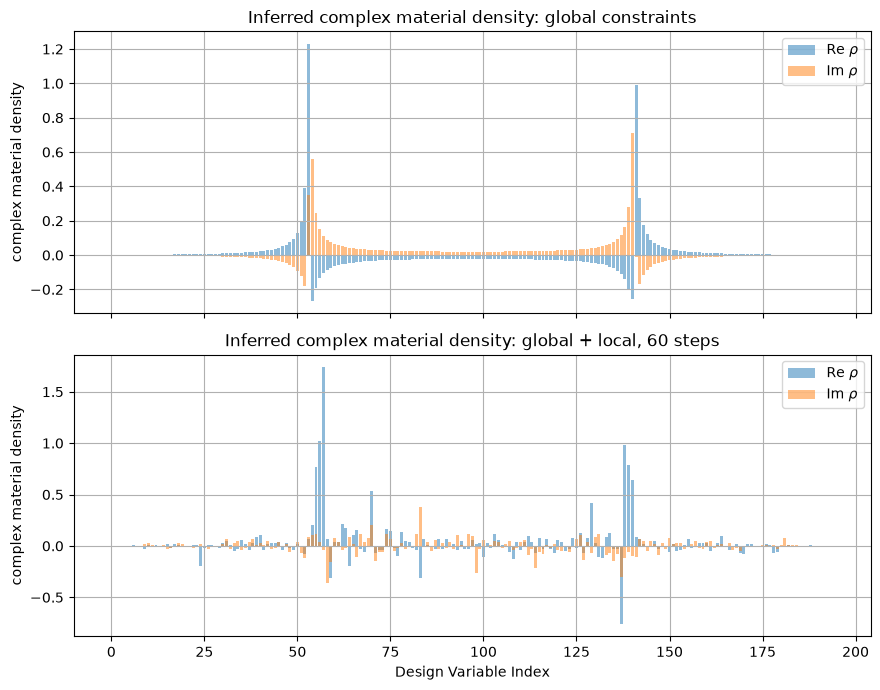

In [24]:
def complexDensity(Vtot):
    # inferred complex material density rho = Zs I / Vtot (Cholesky space)
    return Zs*VtoI(Vtot)/Vtot

rhoGlob = complexDensity(QCQP.current_xstar)    # global constraints
rhoLoc = complexDensity(lQCQP.current_xstar)    # after Nloc local projector steps
cases = [("global constraints", rhoGlob), (f"global + local, {Nloc} steps", rhoLoc)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], "
          f"Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()